In [ ]:
#Winston Shih
#WXS190012
#MATH 4332 Homework 8
#1
import numpy as np
from numpy.linalg import cond, matrix_rank
def linind(h):
  p=matrix_rank(h)
  return h[:,:p]
H1 = np.array([[4,2,1,0,-3],
              [6,3,0,0,-6],
              [0,0,-1,0,-1]])
H2 = np.array([[12,24,0,11,-24,18,15],
              [19,38,0,10,-31,25,9],
              [1,2,0,21,-5,3,20],
              [6,12,0,13,-10,8,5],
              [22,44,0,2,-12,17,23]])
print("H1's linearly independent columns:")
print(linind(H1))
print("H2's linearly independent columns:")
print(linind(H2))

H1's linearly independent columns:
[[4 2]
 [6 3]
 [0 0]]
H2's linearly independent columns:
[[12 24  0 11]
 [19 38  0 10]
 [ 1  2  0 21]
 [ 6 12  0 13]
 [22 44  0  2]]


In [ ]:
#2
import math
import numpy as np
from numpy import dot, arccos
from numpy.linalg import norm
def my_is_similar(s1,s2,tol):
  if tol<=0:
    print("Tol should be a scalar value greater than 0.")
    return 0
  else:
    v1=[0]*26
    v2=[0]*26
    for i, char in enumerate("abcdefghijklmnopqrstuvwxyz"):
      v1[i] = s1.lower().count(char)
      v2[i] = s2.lower().count(char)
    theta = arccos(dot(v1,v2)/(norm(v1)*norm(v2)))
    tol=(np.pi/180)*tol
    if abs(theta) < tol:
      return 1
    else:
      return 0
print(my_is_similar("His","Hers",90))

1


In [ ]:
#3a
import numpy as np
from numpy.linalg import eig
A=[[2,1,2],
   [1,3,2],
   [2,4,1]]
x=([1, 1, 1])
def normalize(x):
  fac=x[np.argmax(np.abs(x))]
  x_n=x/fac
  return fac, x_n
lambda_1=0
iteration=0
for i in range(20):
    x = np.dot(A, x)
    lambda_2, x = normalize(x)
    if (abs(lambda_2-lambda_1)/lambda_2)<1e-10:
        break
    iteration+=1
    lambda_1=lambda_2
eigenvalue, eigenvector=lambda_2, x
print('E-value:', lambda_1)
print('E-vector', x)
print('Iteration in which relative difference < 10^-10: ',iteration)

E-value: 6.029111919859662
E-vector [0.7191869  0.89768453 1.        ]
Iteration in which relative difference < 10^-10:  16


In [ ]:
#3b
from numpy.linalg import inv
A=[[2,1,2],
   [1,3,2],
   [2,4,1]]
x=([1, 1, 1])
def normalize(x):
  fac=x[np.argmax(np.abs(x))]
  x_n=x/fac
  return fac, x_n
InvA=inv(A)
for i in range(20):
    x = np.dot(InvA, x)
    lambda_1, x = normalize(x)
print('Smallest eigenvalue of A:', 1/lambda_1)
print('Its corresponding eigenvector:', x)

Smallest eigenvalue of A: -0.74662034018258
Its corresponding eigenvector: [ 1.         -0.20855702 -0.56047464]


In [ ]:
#3c
import numpy as np
from numpy.linalg import qr
A=[[2,1,2],
   [1,3,2],
   [2,4,1]]
q, r = qr(A)
print('Q:\n', q)
print('R:\n', r)

B = np.dot(q, r)
print('QR:\n', B)

Q:
 [[-0.66666667  0.7028635  -0.24806947]
 [-0.33333333 -0.57882876 -0.74420841]
 [-0.66666667 -0.41344912  0.62017367]]
R:
 [[-3.         -4.33333333 -2.66666667]
 [ 0.         -2.68741925 -0.16537965]
 [ 0.          0.         -1.36438208]]
QR:
 [[2. 1. 2.]
 [1. 3. 2.]
 [2. 4. 1.]]


In [ ]:
#3d
import numpy as np
from numpy.linalg import qr
A=[[2,1,2],
   [1,3,2],
   [2,4,1]]
def normalize(x):
  fac=x[np.argmax(np.abs(x))]
  x_n=x/fac
  return fac, x_n
lambda_1=0
for i in range(1000):
  q, r = qr(A)
  A = np.dot(r, q)
  lambda_2, x = normalize(x)
  if (abs(lambda_2-lambda_1)/lambda_2)<1e-10:
    break
print("Eigenvalues:", np.diag(A))

Eigenvalues: [ 6.02911192 -1.36536789  1.33625597]


In [ ]:
#3e
import numpy as np
from numpy.linalg import eig
A=[[2,1,2],
   [1,3,2],
   [2,4,1]]
w,v=eig(A)
print('Eigen values:', w)
print('Eigen vector:\n', v)

Eigen values: [ 6.02911192  1.33625596 -1.36536788]
Eigen vector:
 [[-0.47185751 -0.88987496 -0.42138925]
 [-0.58896955  0.45081499 -0.29617582]
 [-0.65609859  0.0699171   0.85715284]]


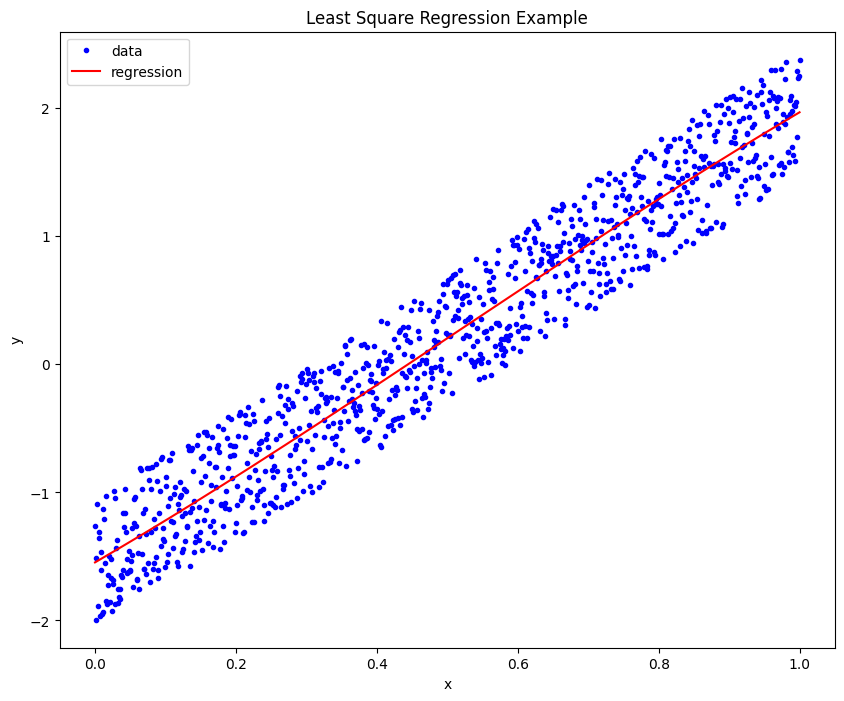

In [ ]:
#5
import numpy as np
import matplotlib.pyplot as plt
x = np.linspace(0, 1, 1000)
def my_lin_regression(f, x, y):
  A = np.vstack([f[i](x) for i in range(len(f))]).T
  beta = np.linalg.lstsq(A, y, rcond=None)[0]
  return beta
y = 3*np.sin(x) - 2*np.cos(x) + np.random.random(len(x))
f = [np.sin, np.cos, np.ones_like]
beta = my_lin_regression(f, x, y)
plt.figure(figsize = (10,8))
plt.plot(x,y,'b.', label = 'data')
plt.plot(x, beta[0]*f[0](x)+beta[1]*f[1](x)+beta[2], 'r', label='regression')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Least Square Regression Example')
plt.legend()
plt.show()

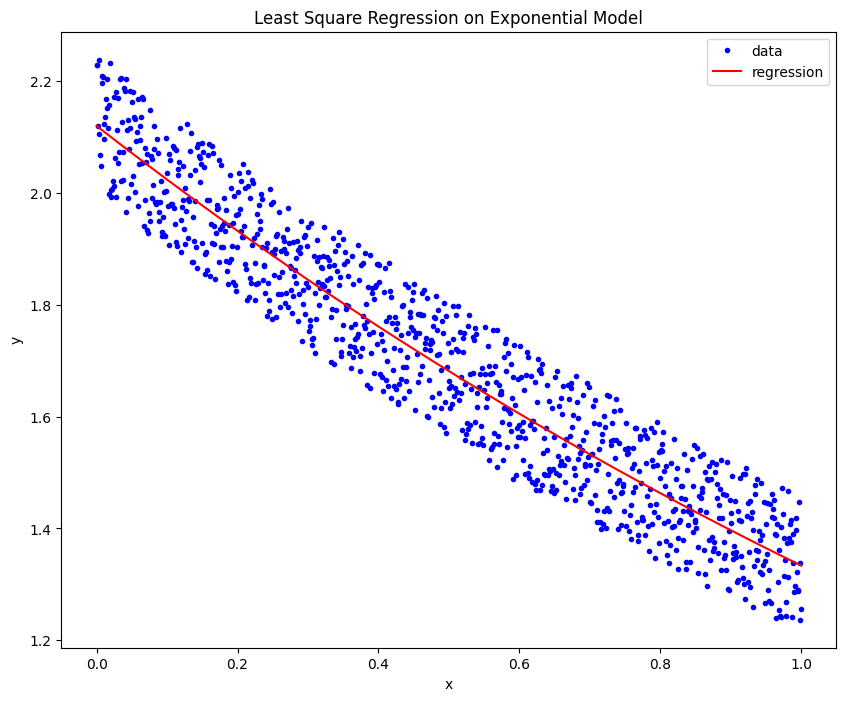

In [ ]:
#6
import numpy as np
import matplotlib.pyplot as plt
def my_exp_regression(x, y):
  A = np.vstack([x, np.ones(len(x))]).T
  alpha, ln_beta = np.linalg.lstsq(A, np.log(y), rcond=None)[0]
  return alpha, np.exp(ln_beta)
x = np.linspace(0, 1, 1000)
y = 2*np.exp(-0.5*x) + 0.25*np.random.random(len(x))
alpha, beta = my_exp_regression(x, y)
plt.figure(figsize = (10,8))
plt.plot(x,y,'b.', label = 'data')
plt.plot(x, beta*np.exp(alpha*x), 'r', label='regression')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Least Square Regression on Exponential Model')
plt.legend()
plt.show()